<a href="https://colab.research.google.com/github/gaelosvaldor-star/Tercer-paracial-/blob/main/Bootstrap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Bootstrap

El **bootstrap** es un método de remuestreo que permite estimar la distribución muestral de un estadístico (y con ella su error estándar e intervalos de confianza) sin suponer una forma paramétrica para la población.

Supongamos que $X_1,\dots,X_n$ son variables aleatorias independientes con función de distribución común $F$. Queremos estimar un parámetro $\theta(F)$ mediante el estimador $g(X_1,\dots,X_n)$. El error cuadrático medio del estimador es

$$ECM(F)=E_F\!\left[\big(g(X_1,\dots,X_n)-\theta(F)\big)^2\right]$$

Como $F$ es desconocida, la estimamos con la **distribución empírica**

$$F_e(x)=\frac{\#\{\,i:X_i\le x\,\}}{n}$$

que asigna probabilidad $1/n$ a cada observación. El bootstrap consiste en remuestrear de $F_e$ (tomar muestras de tamaño $n$ **con reemplazo** de los datos originales) y recalcular el estadístico en cada muestra.

**Procedimiento (para estimar la media):**

1. A partir de la muestra original de $n$ observaciones, generar $B$ muestras bootstrap remuestreando con reemplazo de $F_e$.
2. Para cada muestra $b=1,\dots,B$ calcular su media $\bar{x}^{*}_b$.
3. Con las $B$ medias: obtener la media de las medias, calcular la desviación estándar (que estima el error estándar) y determinar los percentiles $2.5\%$ y $97.5\%$ para construir el intervalo de confianza del $95\%$.

In [ ]:
import numpy as np
import random as r
import statistics as st
import scipy.stats as stats
import matplotlib.pyplot as plt

In [ ]:

datos = [35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]

n = len(datos)        # tamaño de la muestra
B = 1000              # número de muestras bootstrap
np.random.seed(42)    # semilla para reproducir resultados

def bootstrap_media(datos, B):
    n = len(datos)
    medias = np.empty(B)
    for b in range(B):
        muestra = np.random.choice(datos, size=n, replace=True)  # remuestreo de F_e
        medias[b] = muestra.mean()                               # media de la muestra b
    return medias

medias = bootstrap_media(datos, B)

media_boot = medias.mean()
desv_est   = medias.std(ddof=1)                 # estima el error estándar de la media
li, ls     = np.percentile(medias, [2.5, 97.5]) # percentiles 2.5% y 97.5%

print(f"Media muestral original : {st.mean(datos):.4f}")
print(f"Media de las {B} medias  : {media_boot:.4f}")
print(f"Desviación estándar      : {desv_est:.4f}")
print(f"IC bootstrap del 95%     : [{li:.4f}, {ls:.4f}]")


Media muestral original : 40.0000
Media de las 1000 medias  : 39.9278
Desviación estándar      : 0.8326
IC bootstrap del 95%     : [38.2500, 41.5833]


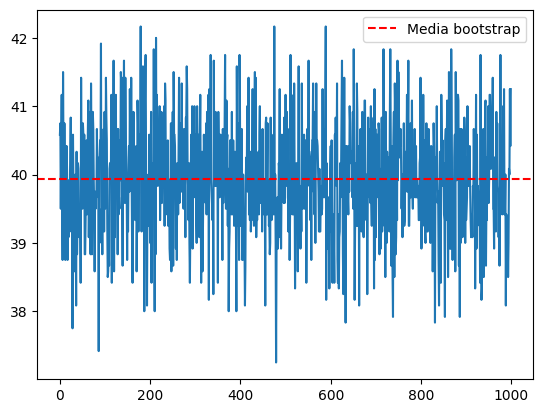

In [ ]:
promedio_boot = sum(medias)/len(medias)

plt.plot(medias)
plt.axhline(y=promedio_boot, color='r', linestyle='--', label='Media bootstrap')
plt.legend()
plt.show()